In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

- Analyse effect of varying delay durations in 5 minute increments (5,10,15,20) to determine if adjustments to the transfer window are necessary. This is done by increasing the time gap by the delay duration
- We will treat our own classifier as the ground truth on how journeys should be grouped.
- For the transfer window, increment bus transfer window (includes bus-bus, bus-train, train-bus) by 5 minutes from 35mins to 60mins, while holding train-train transfers fixed at 15min
- Justification for holding train-train transfers fixed at 15min is that true transfer mostly only occur at certain stations (e.g. Newton) and there are a very low proportion of valid train-train transfers initially 
- Our goal is to test whether the transfer window that is specifically chose (e.g. 45min by LTA currently) is robust enough to handle delays
- We will calculate wrongly split and wrong merged rates. 
- Wrongly split: classifier says the pair is a transfer (same journey), but the window says the gap is too long and breaks them apart
- Wrongly merged: classifier says the pair is a new journey, but the window links them as a transfer 

In [2]:
RAIL_RAIL_WINDOW = 15
bus_windows = list(range(35, 65, 5))   # 35, 40, 45, 50, 55, 60
delay_scenarios = [0, 5, 10, 15, 20]

Baseline spec

In [3]:
df4_with_regions = pd.read_pickle('../data/df4_with_regions.pkl')

In [4]:
df4_lenient_with_regions = pd.read_pickle('../data/df4_lenient_with_regions.pkl')

In [5]:
df4_strict_with_regions =  pd.read_pickle('../data/df4_strict_with_regions.pkl')

In [6]:
specs = {
    'baseline': df4_with_regions,
    'lenient':  df4_lenient_with_regions,
    'strict':   df4_strict_with_regions,
}

Justification for not altering train-train window

In [7]:
print("Mode pair distribution in baseline df:")
print(df4_with_regions['mode_pair'].value_counts(dropna=False))

train_train = df4_with_regions[df4_with_regions['mode_pair'] == 'train_train'].copy()

print(f"\nTrain-train pairs: {len(train_train):,}")
print(f"Train-train as % of all rows: {(len(train_train) / len(df4_with_regions)) * 100:.2f}%")

print("\nTrain-train time gap summary:")
print(train_train['time_gap_mins'].describe())

print(f"\nWithin 15 mins: {(train_train['time_gap_mins'] <= 15).sum():,}")
print(f"Exceeds 15 mins: {(train_train['time_gap_mins'] > 15).sum():,}")
print(f"Same station consecutive: {train_train['same_station_consecutive'].sum():,}")

Mode pair distribution in baseline df:
mode_pair
other          2467972
bus_bus        1943582
train_train    1308387
bus_train       981197
train_bus       978194
Name: count, dtype: int64

Train-train pairs: 1,308,387
Train-train as % of all rows: 17.04%

Train-train time gap summary:
count    1.227762e+06
mean     3.104246e+02
std      2.520272e+02
min     -1.096667e+02
25%      7.565000e+01
50%      2.322500e+02
75%      5.633500e+02
max      1.370400e+03
Name: time_gap_mins, dtype: float64

Within 15 mins: 116,087
Exceeds 15 mins: 1,111,675
Same station consecutive: 987,581


In [8]:
'''# overall count of train-train pairs
print("Mode pair distribution in df_pairs:")
print(df4_with_regions['mode_pair'].value_counts(dropna=False))
print(f"\nTrain-train pairs: {(df4_with_regions['mode_pair'] == 'train_train').sum():,}")
print(f"Train-train as % of all pairs: {(df4_with_regions['mode_pair'] == 'train_train').mean()*100:.2f}%")

# of train-train transfers, how many are valid transfers under 15min rule
train_train = df4_with_regions[df4_with_regions['mode_pair'] == 'train_train']
print(f"\nOf train-train pairs:")
print(f"  Within 15 mins (valid): {(train_train['time_gap_mins'] <= 15).sum():,}")
print(f"  Exceeds 15 mins:        {(train_train['time_gap_mins'] > 15).sum():,}")
print(f"  Same station consec:    {train_train['same_station_consecutive'].sum():,}")

# distribution of their time gaps
print("\nTime gap distribution for train-train pairs:")
print(train_train['time_gap_mins'].describe())'''

'# overall count of train-train pairs\nprint("Mode pair distribution in df_pairs:")\nprint(df4_with_regions[\'mode_pair\'].value_counts(dropna=False))\nprint(f"\nTrain-train pairs: {(df4_with_regions[\'mode_pair\'] == \'train_train\').sum():,}")\nprint(f"Train-train as % of all pairs: {(df4_with_regions[\'mode_pair\'] == \'train_train\').mean()*100:.2f}%")\n\n# of train-train transfers, how many are valid transfers under 15min rule\ntrain_train = df4_with_regions[df4_with_regions[\'mode_pair\'] == \'train_train\']\nprint(f"\nOf train-train pairs:")\nprint(f"  Within 15 mins (valid): {(train_train[\'time_gap_mins\'] <= 15).sum():,}")\nprint(f"  Exceeds 15 mins:        {(train_train[\'time_gap_mins\'] > 15).sum():,}")\nprint(f"  Same station consec:    {train_train[\'same_station_consecutive\'].sum():,}")\n\n# distribution of their time gaps\nprint("\nTime gap distribution for train-train pairs:")\nprint(train_train[\'time_gap_mins\'].describe())'

In [9]:
#helper function to build df_pairs for each spec df
def build_df_pairs(df):
    crds_with_missing = df[
        (df['is_last_stage'] == False) &
        (df['time_gap_mins'].isna())
    ]['CRD_NUM'].unique()

    df_pairs = df[
        (df['is_last_stage'] == False) &
        (~df['CRD_NUM'].isin(crds_with_missing)) &
        (df['PATRON_CATG_DESC_TXT'].notna())
    ].copy()

    print(f"  Cards removed (missing gap): {len(crds_with_missing):,}")
    print(f"  Ride pairs remaining:        {len(df_pairs):,}")

    return df_pairs

In [10]:
classifier_journeys_map = {}
classifier_journeys_patron_map = {}

for spec_name, df_raw in specs.items():
    # Total journeys per card
    journeys_per_card = (
        df_raw.groupby('CRD_NUM')['final_journey_seq']
              .max()
              .add(1)
    )
    classifier_journeys_map[spec_name] = int(journeys_per_card.sum())

    # Optional: per patron
    journeys_patron = (
        df_raw.groupby(['PATRON_CATG_DESC_TXT', 'CRD_NUM'])['final_journey_seq']
              .max()
              .add(1)
              .reset_index()
    )
    journeys_patron = (
        journeys_patron.groupby('PATRON_CATG_DESC_TXT')['final_journey_seq']
                       .sum()
                       .to_dict()
    )
    classifier_journeys_patron_map[spec_name] = journeys_patron

In [11]:
def aggregate(df, group_col=None):
    rows = []
    groups = [None] if group_col is None else df[group_col].dropna().unique()

    for grp_val in groups:
        sub = df if grp_val is None else df[df[group_col] == grp_val]

        if len(sub) == 0:
            continue

        total_true = sub['ground_truth_transfer'].sum()
        total_non = (~sub['ground_truth_transfer']).sum()

        for delay in delay_scenarios:
            for bus_window in bus_windows:
                ws = sub[f'wrongly_split_{delay}_{bus_window}'].sum()
                wm = sub[f'wrongly_merged_{delay}_{bus_window}'].sum()

                if group_col is None:
                    wt = sub[f'window_transfer_{delay}_{bus_window}']
                    window_breaks = (~wt).sum()
                    n_cards = sub['CRD_NUM'].nunique()
                    window_journeys = int(window_breaks + n_cards)
                else:
                    window_journeys = np.nan

                row = {
                    'n_pairs': len(sub),
                    'ground_truth_transfer_n': total_true,
                    'ground_truth_new_journey_n': total_non,
                    'delay_mins': delay,
                    'bus_window_mins': bus_window,
                    'window_journeys': window_journeys,
                    'wrongly_split_n': ws,
                    'wrongly_merged_n': wm,
                    'wrongly_split_pct': ws / total_true * 100 if total_true > 0 else np.nan,
                    'wrongly_merged_pct': wm / total_non * 100 if total_non > 0 else np.nan,
                    'wrongly_split_pct_all': ws / len(sub) * 100,
                    'wrongly_merged_pct_all': wm / len(sub) * 100,
                }

                if group_col is not None:
                    row[group_col] = grp_val

                rows.append(row)

    return pd.DataFrame(rows)

In [12]:
all_overall = []
all_patron = []
all_dest_region = []
all_orig_region = []
all_hour = []

In [13]:
for spec_name, df_raw in specs.items():
    print(f"\n{'='*50}")
    print(f"Spec: {spec_name}")
    print(f"{'='*50}")

    df_pairs = build_df_pairs(df_raw)

    # fixed classifier truth
    df_pairs['ground_truth_transfer'] = df_pairs['is_same_journey_final']
    df_pairs['next_entry_hour'] = df_pairs['next_ENTRY_TM'].dt.hour

    print(f"  True transfers:    {df_pairs['ground_truth_transfer'].sum():,}")
    print(f"  True new journeys: {(~df_pairs['ground_truth_transfer']).sum():,}")

    new_cols = {}

    for delay in delay_scenarios:
        delayed_gap = df_pairs['time_gap_mins'] + delay
        new_cols[f'delayed_gap_{delay}'] = delayed_gap

        for bus_window in bus_windows:
            effective_window = np.where(
                df_pairs['mode_pair'] == 'train_train',
                RAIL_RAIL_WINDOW,
                bus_window
            )

            window_transfer = (
                delayed_gap <= effective_window
            )

            wrongly_split = df_pairs['ground_truth_transfer'] & ~window_transfer
            wrongly_merged = ~df_pairs['ground_truth_transfer'] & window_transfer

            new_cols[f'window_transfer_{delay}_{bus_window}'] = window_transfer
            new_cols[f'wrongly_split_{delay}_{bus_window}'] = wrongly_split
            new_cols[f'wrongly_merged_{delay}_{bus_window}'] = wrongly_merged

            total_true = df_pairs['ground_truth_transfer'].sum()
            total_non = (~df_pairs['ground_truth_transfer']).sum()

            print(
                f"  delay={delay:>2}min | window={bus_window}min | "
                f"wrongly_split={wrongly_split.sum():,} ({wrongly_split.sum()/total_true*100:.2f}%) | "
                f"wrongly_merged={wrongly_merged.sum():,} ({wrongly_merged.sum()/total_non*100:.2f}%)"
            )

    df_pairs = pd.concat(
        [df_pairs, pd.DataFrame(new_cols, index=df_pairs.index)],
        axis=1
    )

    print(f"\n  Precomputed columns: {len(new_cols)}")

    overall_tmp = aggregate(df_pairs, group_col=None)
    patron_tmp = aggregate(df_pairs, group_col='PATRON_CATG_DESC_TXT')
    dest_region_tmp = aggregate(df_pairs, group_col='dest_region')
    orig_region_tmp = aggregate(df_pairs, group_col='orig_region')
    hour_tmp = aggregate(df_pairs, group_col='next_entry_hour')

    overall_tmp['spec'] = spec_name
    patron_tmp['spec'] = spec_name
    dest_region_tmp['spec'] = spec_name
    orig_region_tmp['spec'] = spec_name
    hour_tmp['spec'] = spec_name

    all_overall.append(overall_tmp)
    all_patron.append(patron_tmp)
    all_dest_region.append(dest_region_tmp)
    all_orig_region.append(orig_region_tmp)
    all_hour.append(hour_tmp)

    print(f"\n  Done: {spec_name}")


Spec: baseline
  Cards removed (missing gap): 28,144
  Ride pairs remaining:        4,753,028
  True transfers:    1,581,202
  True new journeys: 3,171,826
  delay= 0min | window=35min | wrongly_split=462 (0.03%) | wrongly_merged=690,725 (21.78%)
  delay= 0min | window=40min | wrongly_split=453 (0.03%) | wrongly_merged=734,043 (23.14%)
  delay= 0min | window=45min | wrongly_split=453 (0.03%) | wrongly_merged=772,238 (24.35%)
  delay= 0min | window=50min | wrongly_split=453 (0.03%) | wrongly_merged=806,454 (25.43%)
  delay= 0min | window=55min | wrongly_split=453 (0.03%) | wrongly_merged=838,150 (26.42%)
  delay= 0min | window=60min | wrongly_split=453 (0.03%) | wrongly_merged=867,654 (27.36%)
  delay= 5min | window=35min | wrongly_split=2,318 (0.15%) | wrongly_merged=625,107 (19.71%)
  delay= 5min | window=40min | wrongly_split=2,124 (0.13%) | wrongly_merged=674,308 (21.26%)
  delay= 5min | window=45min | wrongly_split=2,115 (0.13%) | wrongly_merged=717,626 (22.63%)
  delay= 5min | wi

In [14]:
overall_df = pd.concat(all_overall, ignore_index=True)
patron_df = pd.concat(all_patron, ignore_index=True)
dest_region_df = pd.concat(all_dest_region, ignore_index=True)
orig_region_df = pd.concat(all_orig_region, ignore_index=True)
hour_df = pd.concat(all_hour, ignore_index=True)

overall_df['breakdown_type'] = 'overall'
overall_df['breakdown_value'] = 'overall'

patron_df['breakdown_type'] = 'patron'
patron_df = patron_df.rename(columns={'PATRON_CATG_DESC_TXT': 'breakdown_value'})

dest_region_df['breakdown_type'] = 'dest_region'
dest_region_df = dest_region_df.rename(columns={'dest_region': 'breakdown_value'})

orig_region_df['breakdown_type'] = 'orig_region'
orig_region_df = orig_region_df.rename(columns={'orig_region': 'breakdown_value'})

hour_df['breakdown_type'] = 'next_entry_hour'
hour_df = hour_df.rename(columns={'next_entry_hour': 'breakdown_value'})

overall_df['classifier_journeys'] = overall_df['spec'].map(classifier_journeys_map)

# keep journey totals only for overall
def _lookup_patron_journeys(row):
    return classifier_journeys_patron_map.get(row['spec'], {}).get(row['breakdown_value'], np.nan)

patron_df['classifier_journeys'] = patron_df.apply(_lookup_patron_journeys, axis=1)
patron_df['window_journeys'] = np.nan

dest_region_df['classifier_journeys'] = np.nan
dest_region_df['window_journeys'] = np.nan

orig_region_df['classifier_journeys'] = np.nan
orig_region_df['window_journeys'] = np.nan

hour_df['classifier_journeys'] = np.nan
hour_df['window_journeys'] = np.nan

final_df = pd.concat(
    [overall_df, patron_df, dest_region_df, orig_region_df, hour_df],
    ignore_index=True
)

col_order = [
    'spec', 'breakdown_type', 'breakdown_value',
    'delay_mins', 'bus_window_mins',
    'n_pairs',
    'classifier_journeys',
    'window_journeys',
    'ground_truth_transfer_n', 'ground_truth_new_journey_n',
    'wrongly_split_n', 'wrongly_merged_n',
    'wrongly_split_pct', 'wrongly_merged_pct',
    'wrongly_split_pct_all', 'wrongly_merged_pct_all',
]

final_df = final_df[col_order]

print(f"\nFinal shape: {final_df.shape}")
# final_df.to_csv('../data/lta_delay_sim_results.csv', index=False)




Final shape: (11250, 16)


In [15]:
df4_card = (
    df4_with_regions
    .groupby('CRD_NUM')['final_journey_seq']
    .max()
    .add(1)
)

baseline_card = (
    specs['baseline']
    .groupby('CRD_NUM')['final_journey_seq']
    .max()
    .add(1)
)

comparison = pd.DataFrame({
    'df4': df4_card,
    'baseline': baseline_card
})

comparison['match'] = comparison['df4'] == comparison['baseline']

print("Mismatch cards:", (~comparison['match']).sum())

Mismatch cards: 0


In [16]:
def query_delay_sim(
    delay_mins: int,
    bus_window: int,
    classifier_type: str,   # 'baseline', 'lenient', 'strict'
    patron: str = 'all',
    df: pd.DataFrame = None
):
    """
    Returns summary + breakdowns for delay simulation, with journeys computed per patron.

    Parameters
    ----------
    delay_mins : int
        Delay in minutes (0,5,10,15,20)
    bus_window : int
        Transfer window in minutes (35,40,...,60)
    classifier_type : str
        'baseline', 'lenient', 'strict'
    patron : str
        'all', 'Student', 'Adult', 'Senior Citizen'
    df : pd.DataFrame
        The precomputed results CSV (final_df)

    Returns
    -------
    dict
    """
    if df is None:
        raise ValueError("Please provide a DataFrame with precomputed results (final_df)")

    valid_delays = [0, 5, 10, 15, 20]
    valid_windows = list(range(35, 65, 5))
    valid_specs = ['baseline', 'lenient', 'strict']

    if delay_mins not in valid_delays:
        raise ValueError(f"delay_mins must be one of {valid_delays}")
    if bus_window not in valid_windows:
        raise ValueError(f"bus_window must be one of {valid_windows}")
    if classifier_type not in valid_specs:
        raise ValueError(f"classifier_type must be one of {valid_specs}")

    sub = df[
        (df['delay_mins'] == delay_mins) &
        (df['bus_window_mins'] == bus_window) &
        (df['spec'] == classifier_type)
    ].copy()

    if sub.empty:
        raise ValueError("No data found for given parameters")

    if patron == 'all':
        overall_row = sub[sub['breakdown_type'] == 'overall'].iloc[0]
        main_row = overall_row
        classifier_journeys = int(overall_row['classifier_journeys']) if not pd.isna(overall_row['classifier_journeys']) else None
        window_journeys = int(overall_row['window_journeys']) if not pd.isna(overall_row['window_journeys']) else None
    else:
        patron_rows = sub[sub['breakdown_type'] == 'patron']
        if patron not in patron_rows['breakdown_value'].values:
            raise ValueError(f"Patron '{patron}' not found")
        main_row = patron_rows[patron_rows['breakdown_value'] == patron].iloc[0]
        classifier_journeys = int(main_row['classifier_journeys']) if not pd.isna(main_row['classifier_journeys']) else None
        window_journeys = None  # not computed at patron level

    journey_difference = None if (window_journeys is None or classifier_journeys is None) else int(window_journeys - classifier_journeys)

    def get_breakdown(breakdown_type, col_name):
        df_break = sub[sub['breakdown_type'] == breakdown_type].copy()

        df_break = df_break[[
            'breakdown_value',
            'n_pairs',
            'wrongly_split_n',
            'wrongly_merged_n',
            'wrongly_split_pct',
            'wrongly_merged_pct',
            'wrongly_split_pct_all',
            'wrongly_merged_pct_all'
        ]].rename(columns={'breakdown_value': col_name}) \
         .sort_values('wrongly_split_pct', ascending=False) \
         .reset_index(drop=True)

        return df_break

    return {
        'spec': classifier_type,
        'delay_mins': delay_mins,
        'bus_window_mins': bus_window,
        'patron': patron,
        'classifier_journeys': classifier_journeys,
        'window_journeys': window_journeys,
        'journey_difference': journey_difference,
        'wrongly_split_n': int(main_row['wrongly_split_n']),
        'wrongly_merged_n': int(main_row['wrongly_merged_n']),
        'wrongly_split_pct': float(main_row['wrongly_split_pct']),
        'wrongly_merged_pct': float(main_row['wrongly_merged_pct']),
        'by_patron': get_breakdown('patron', 'patron'),
        'by_dest_region': get_breakdown('dest_region', 'dest_region'),
        'by_orig_region': get_breakdown('orig_region', 'orig_region'),
        'by_hour': get_breakdown('next_entry_hour', 'hour')
    }


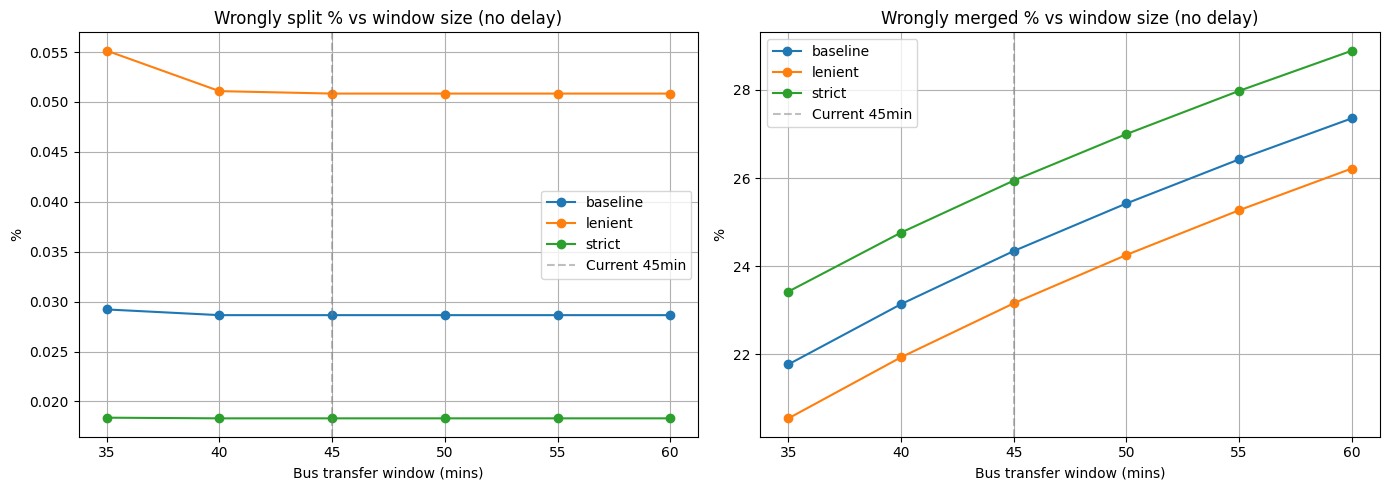

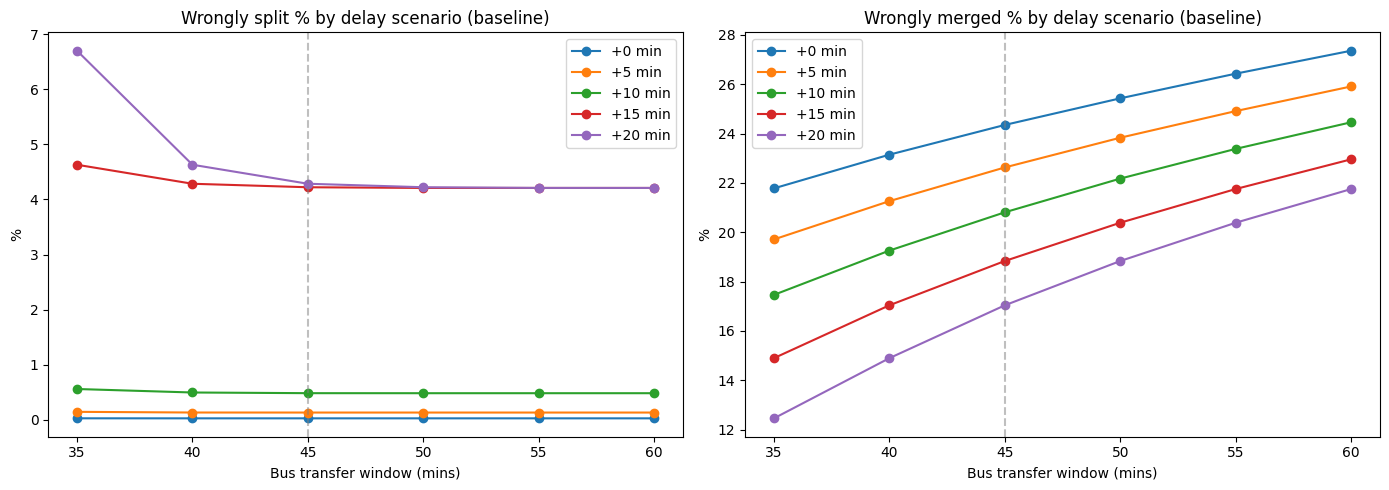

In [17]:
# Plot 1: overall by window, no delay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for spec in ['baseline', 'lenient', 'strict']:
    sub = overall_df[
        (overall_df['spec'] == spec) &
        (overall_df['delay_mins'] == 0)
    ].sort_values('bus_window_mins')

    axes[0].plot(sub['bus_window_mins'], sub['wrongly_split_pct'], marker='o', label=spec)
    axes[1].plot(sub['bus_window_mins'], sub['wrongly_merged_pct'], marker='o', label=spec)

for ax, title in zip(axes, ['Wrongly split %', 'Wrongly merged %']):
    ax.set_title(f'{title} vs window size (no delay)')
    ax.set_xlabel('Bus transfer window (mins)')
    ax.set_ylabel('%')
    ax.axvline(45, color='gray', linestyle='--', alpha=0.5, label='Current 45min')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

# Plot 2: baseline by delay scenario
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for delay in delay_scenarios:
    sub = overall_df[
        (overall_df['spec'] == 'baseline') &
        (overall_df['delay_mins'] == delay)
    ].sort_values('bus_window_mins')

    axes[0].plot(sub['bus_window_mins'], sub['wrongly_split_pct'], marker='o', label=f'+{delay} min')
    axes[1].plot(sub['bus_window_mins'], sub['wrongly_merged_pct'], marker='o', label=f'+{delay} min')

for ax, title in zip(axes, ['Wrongly split %', 'Wrongly merged %']):
    ax.set_title(f'{title} by delay scenario (baseline)')
    ax.set_xlabel('Bus transfer window (mins)')
    ax.set_ylabel('%')
    ax.axvline(45, color='gray', linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()


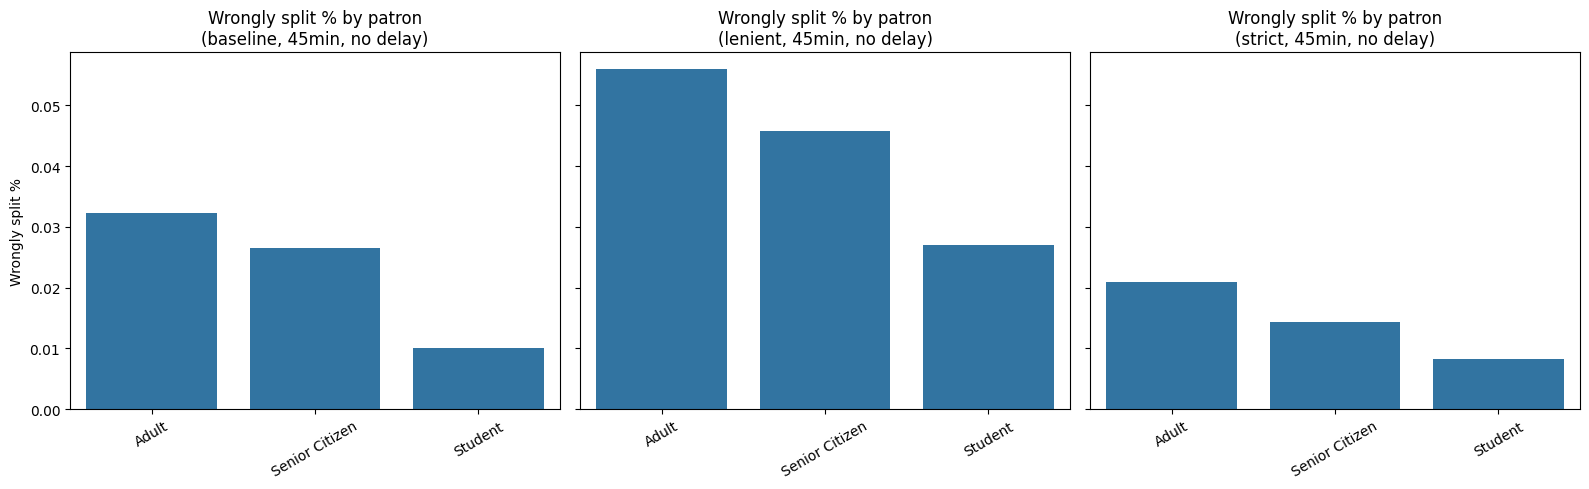

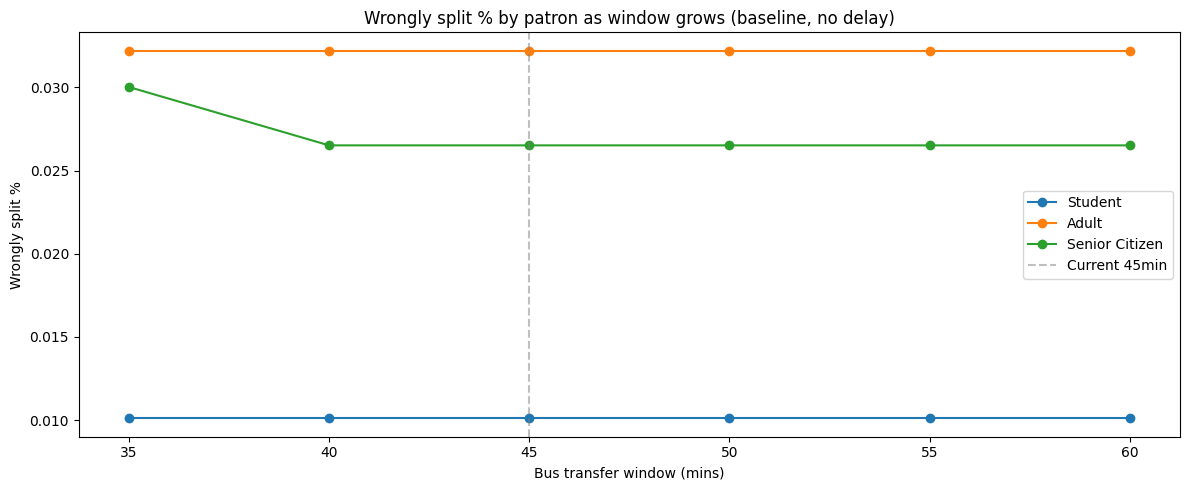

In [18]:
# Plot 3: wrongly split by patron — 45 mins, no delay
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for i, spec in enumerate(['baseline', 'lenient', 'strict']):
    sub = patron_df[
        (patron_df['spec'] == spec) &
        (patron_df['delay_mins'] == 0) &
        (patron_df['bus_window_mins'] == 45)
    ].sort_values('wrongly_split_pct', ascending=False)

    sns.barplot(
        data=sub,
        x='breakdown_value',
        y='wrongly_split_pct',
        ax=axes[i]
    )

    axes[i].set_title(f'Wrongly split % by patron\n({spec}, 45min, no delay)')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Wrongly split %' if i == 0 else '')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Plot 4: wrongly split by patron as window grows
fig, ax = plt.subplots(figsize=(12, 5))

for patron in patron_df['breakdown_value'].dropna().unique():
    sub = patron_df[
        (patron_df['spec'] == 'baseline') &
        (patron_df['delay_mins'] == 0) &
        (patron_df['breakdown_value'] == patron)
    ].sort_values('bus_window_mins')

    ax.plot(sub['bus_window_mins'], sub['wrongly_split_pct'], marker='o', label=patron)

ax.set_title('Wrongly split % by patron as window grows (baseline, no delay)')
ax.set_xlabel('Bus transfer window (mins)')
ax.set_ylabel('Wrongly split %')
ax.axvline(45, color='gray', linestyle='--', alpha=0.5, label='Current 45min')
ax.legend()

plt.tight_layout()
plt.show()


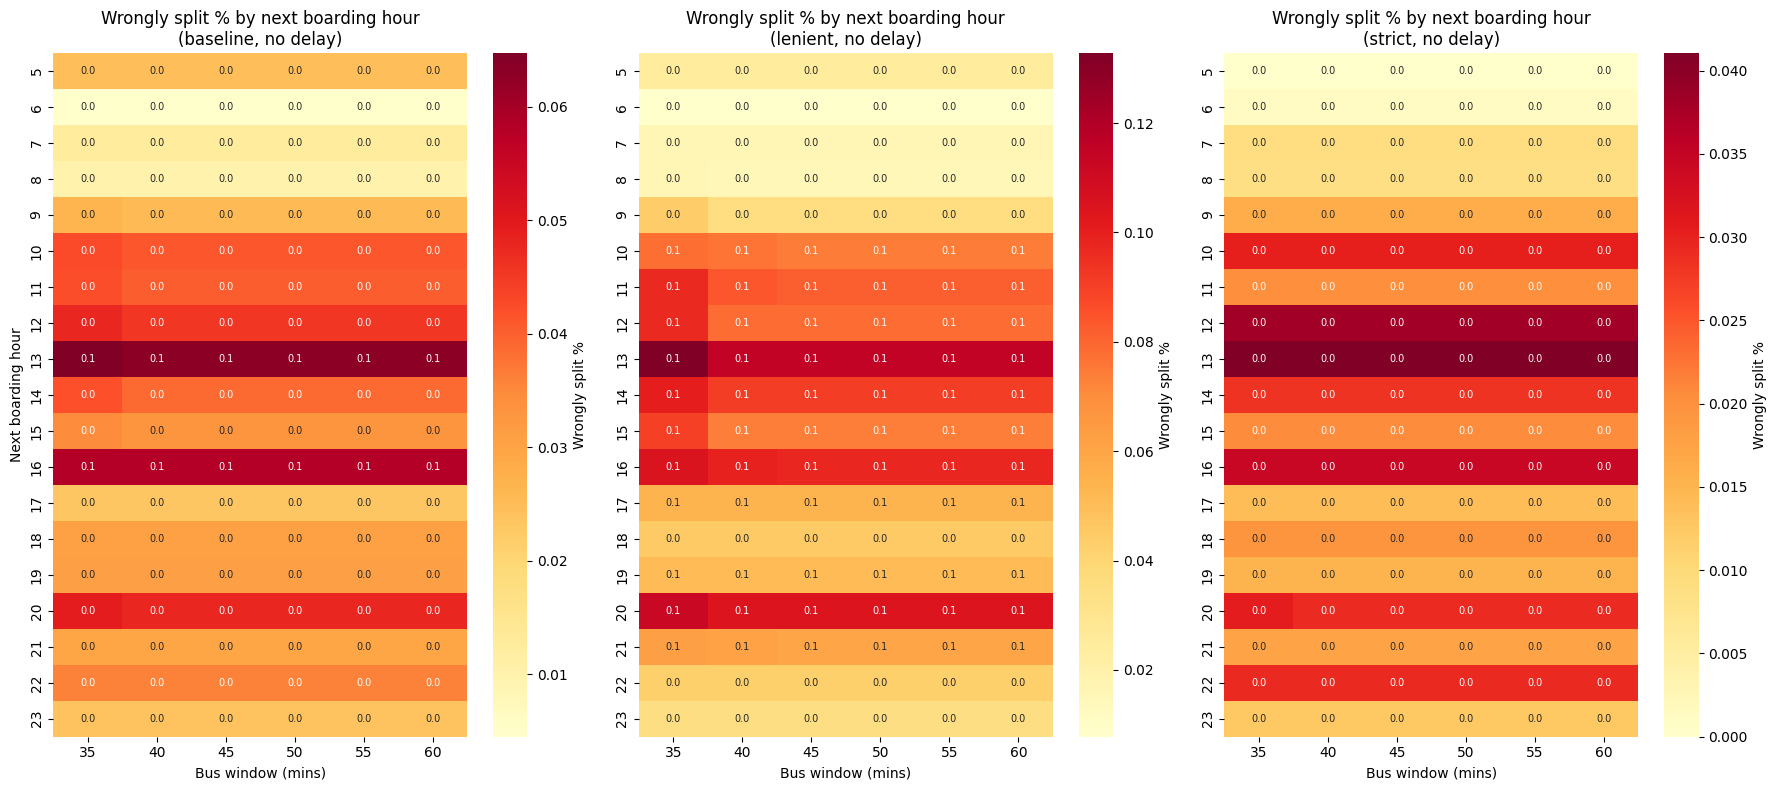

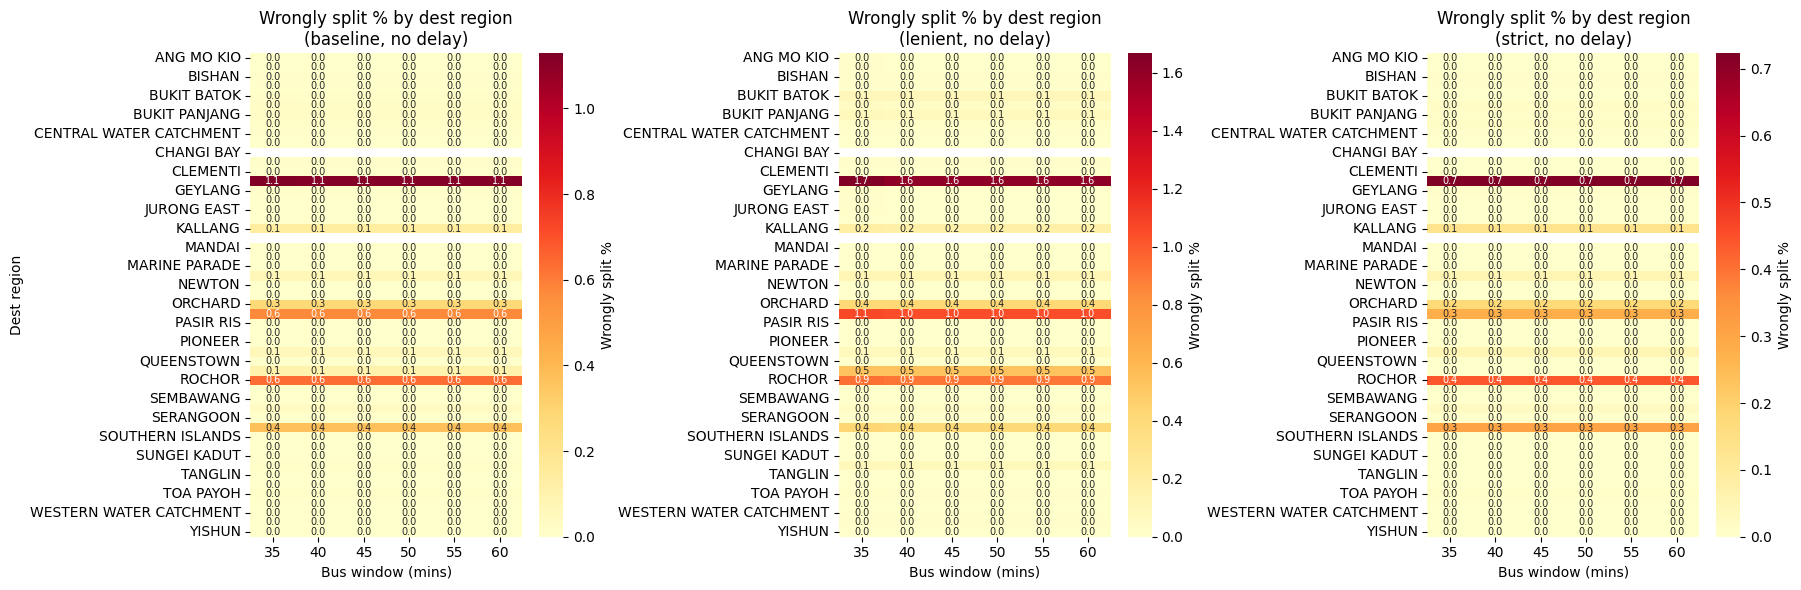

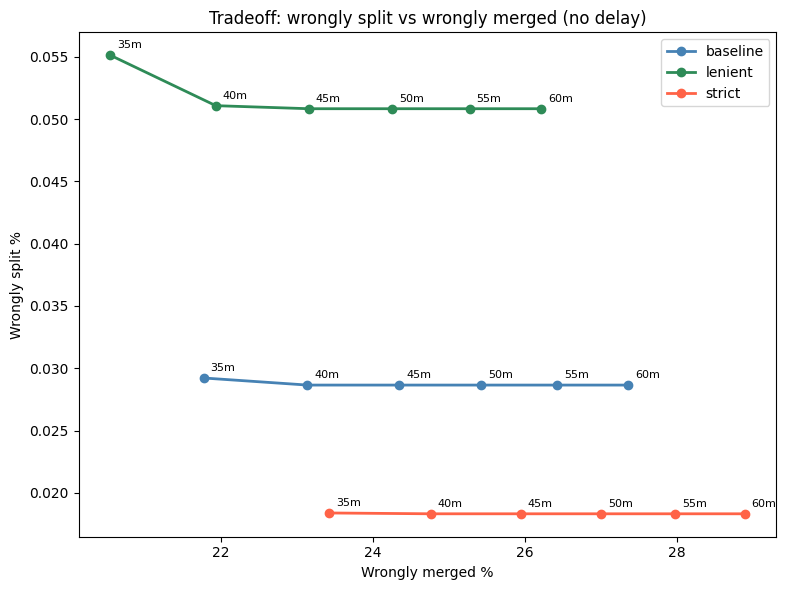

In [19]:
# Plot 5: heatmap by next boarding hour
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for i, spec in enumerate(['baseline', 'lenient', 'strict']):
    pivot = hour_df[
        (hour_df['spec'] == spec) &
        (hour_df['delay_mins'] == 0)
    ].pivot(
        index='breakdown_value',
        columns='bus_window_mins',
        values='wrongly_split_pct'
    ).sort_index()

    sns.heatmap(
        pivot,
        ax=axes[i],
        cmap='YlOrRd',
        fmt='.1f',
        annot=True,
        annot_kws={'size': 7},
        cbar_kws={'label': 'Wrongly split %'}
    )

    axes[i].set_title(f'Wrongly split % by next boarding hour\n({spec}, no delay)')
    axes[i].set_xlabel('Bus window (mins)')
    axes[i].set_ylabel('Next boarding hour' if i == 0 else '')

plt.tight_layout()
plt.show()

# Plot 6: heatmap by destination region
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, spec in enumerate(['baseline', 'lenient', 'strict']):
    pivot = dest_region_df[
        (dest_region_df['spec'] == spec) &
        (dest_region_df['delay_mins'] == 0)
    ].pivot(
        index='breakdown_value',
        columns='bus_window_mins',
        values='wrongly_split_pct'
    )

    sns.heatmap(
        pivot,
        ax=axes[i],
        cmap='YlOrRd',
        fmt='.1f',
        annot=True,
        annot_kws={'size': 7},
        cbar_kws={'label': 'Wrongly split %'}
    )

    axes[i].set_title(f'Wrongly split % by dest region\n({spec}, no delay)')
    axes[i].set_xlabel('Bus window (mins)')
    axes[i].set_ylabel('Dest region' if i == 0 else '')

plt.tight_layout()
plt.show()

# Plot 7: tradeoff curve
fig, ax = plt.subplots(figsize=(8, 6))

colors = {'baseline': 'steelblue', 'lenient': 'seagreen', 'strict': 'tomato'}

for spec in ['baseline', 'lenient', 'strict']:
    sub = overall_df[
        (overall_df['spec'] == spec) &
        (overall_df['delay_mins'] == 0)
    ].sort_values('bus_window_mins')

    ax.plot(
        sub['wrongly_merged_pct'],
        sub['wrongly_split_pct'],
        marker='o',
        label=spec,
        color=colors[spec],
        linewidth=2
    )

    for _, row in sub.iterrows():
        ax.annotate(
            f"{int(row['bus_window_mins'])}m",
            xy=(row['wrongly_merged_pct'], row['wrongly_split_pct']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=8
        )

ax.set_xlabel('Wrongly merged %')
ax.set_ylabel('Wrongly split %')
ax.set_title('Tradeoff: wrongly split vs wrongly merged (no delay)')
ax.legend()

plt.tight_layout()
plt.show()